In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

# -----------------------------
# Step 1. Load simulation results from the LATEST chunk
# -----------------------------
script_dir = os.getcwd()
parent_dir = os.path.dirname(script_dir)

# Find all censored density result files
pattern = os.path.join(parent_dir, 'out', 'FineGridEval_*_censored_density_results_TargetingGRID0.1_nSamples500.pkl')
result_files = sorted(glob.glob(pattern))

if len(result_files) == 0:
    raise FileNotFoundError(f"No result files found matching pattern: {pattern}")

# The chunk files are cumulative (chunk_10 ⊂ chunk_20 ⊂ chunk_30, etc.)
# So we only load the LATEST (largest chunk number) to avoid duplicates
latest_file = result_files[-1]
chunk_num = os.path.basename(latest_file).split('_')[1]

print(f"Available chunk files: {[os.path.basename(f) for f in result_files]}")
print(f"Loading LATEST chunk: {os.path.basename(latest_file)} (chunk {chunk_num})")

with open(latest_file, 'rb') as f:
    density_dfs = pickle.load(f)

# Convert to list if it's a tuple
if isinstance(density_dfs, tuple):
    density_dfs = list(density_dfs)

print(f"Loaded {len(density_dfs)} cumulative simulations from chunk {chunk_num}")

Available chunk files: ['FineGridEval_10_censored_density_results_TargetingGRID0.1_nSamples500.pkl', 'FineGridEval_20_censored_density_results_TargetingGRID0.1_nSamples500.pkl', 'FineGridEval_30_censored_density_results_TargetingGRID0.1_nSamples500.pkl', 'FineGridEval_40_censored_density_results_TargetingGRID0.1_nSamples500.pkl']
Loading LATEST chunk: FineGridEval_40_censored_density_results_TargetingGRID0.1_nSamples500.pkl (chunk 40)
Loaded 40 cumulative simulations from chunk 40


In [2]:
# -----------------------------
# Step 2. Combine the simulation rounds
# -----------------------------
df_all = pd.concat(density_dfs, keys=range(len(density_dfs)), names=['sim_run'])
df_all = df_all.reset_index(level='sim_run').reset_index(drop=True)

print(f"\nCombined dataset shape: {df_all.shape}")
print(f"Columns: {df_all.columns.tolist()}")
print(f"Number of unique grid points: {df_all[['T1', 'T2']].drop_duplicates().shape[0]}")
print(f"Number of simulation runs: {df_all['sim_run'].nunique()}")


Combined dataset shape: (4000, 7)
Columns: ['sim_run', 'T1', 'T2', 'true_density', 'Initial_1', 'Final_5', 'NPMLE_Targeted']
Number of unique grid points: 100
Number of simulation runs: 40


In [3]:
# -----------------------------
# Step 3. Summarize results over simulation runs
# -----------------------------
grouped = df_all.groupby(['T1', 'T2'])

summary_list = []
# Use the actual column names from the density files
methods = ['Initial_1', 'Final_5', 'NPMLE_Targeted']
for (T1_val, T2_val), group in grouped:
    true_val = group['true_density'].iloc[0]
    summary = {'T1': T1_val, 'T2': T2_val, 'true_density': true_val}
    for col in methods:
        fitted_vals = group[col].values
        mean_fitted = np.mean(fitted_vals)
        bias = mean_fitted - true_val
        mse = np.mean((fitted_vals - true_val)**2)
        std = np.std(fitted_vals)
        lower_nom = mean_fitted - 1.96 * std
        upper_nom = mean_fitted + 1.96 * std
        coverage = np.mean((true_val >= (fitted_vals - 1.96 * std)) & (true_val <= (fitted_vals + 1.96 * std)))
        
        summary[f'{col}_mean'] = mean_fitted
        summary[f'{col}_bias'] = bias
        summary[f'{col}_mse'] = mse
        summary[f'{col}_std'] = std
        summary[f'{col}_lower'] = lower_nom
        summary[f'{col}_upper'] = upper_nom
        summary[f'{col}_coverage'] = coverage
    summary_list.append(summary)

df_summary = pd.DataFrame(summary_list)
print(f"\nSummary statistics computed for {len(df_summary)} grid points")
print(df_summary.head())


Summary statistics computed for 100 grid points
    T1        T2  true_density  Initial_1_mean  Initial_1_bias  Initial_1_mse  \
0  0.0  0.000000      0.022578        0.073269        0.050692       0.003760   
1  0.0  0.111111      0.060619        0.121978        0.061358       0.005828   
2  0.0  0.222222      0.127148        0.201619        0.074471       0.008991   
3  0.0  0.333333      0.208342        0.289087        0.080745       0.013116   
4  0.0  0.444444      0.266692        0.325462        0.058770       0.012034   

   Initial_1_std  Initial_1_lower  Initial_1_upper  Initial_1_coverage  ...  \
0       0.034507         0.005635         0.140904               0.725  ...   
1       0.045423         0.032950         0.211006               0.750  ...   
2       0.058697         0.086573         0.316665               0.700  ...   
3       0.081220         0.129895         0.448279               0.825  ...   
4       0.092629         0.143910         0.507015               0.92

In [4]:
df_summary.shape

(100, 24)

In [5]:
# Print overall summary statistics (averaged across the grid) for each method.
methods = ['Initial_1', 'Final_5', 'NPMLE_Targeted']

for col in methods:
    overall_abs_bias = df_summary[f'{col}_bias'].abs().mean()
    overall_std = df_summary[f'{col}_std'].mean()
    overall_mse = df_summary[f'{col}_mse'].mean()
    overall_cov = df_summary[f'{col}_coverage'].median()
    print(f"Method {col}: Overall abs bias = {overall_abs_bias:.4f}, Overall std = {overall_std:.4f}, Overall MSE = {overall_mse:.4f}, Overall coverage = {overall_cov:.3f}")

Method Initial_1: Overall abs bias = 0.3576, Overall std = 0.1248, Overall MSE = 0.2507, Overall coverage = 0.350
Method Final_5: Overall abs bias = 0.1201, Overall std = 0.2070, Overall MSE = 0.0825, Overall coverage = 0.925
Method NPMLE_Targeted: Overall abs bias = 0.1269, Overall std = 0.5353, Overall MSE = 0.4508, Overall coverage = 0.950


In [6]:
# Define the target values and the list of targeting pairs
target_vals = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
targeting_pairs = [(t1, t2) for t1 in target_vals for t2 in target_vals]

# Since the evaluation grid is 10x10, we need to find the nearest grid points to the target values
def find_nearest_indices(df, target_vals, tolerance=0.02):
    """Find rows where T1 and T2 are within tolerance of target values"""
    mask = pd.Series(False, index=df.index)
    for t1 in target_vals:
        for t2 in target_vals:
            mask |= ((df['T1'] - t1).abs() < tolerance) & ((df['T2'] - t2).abs() < tolerance)
    return mask

df_sub = df_summary[find_nearest_indices(df_summary, target_vals, tolerance=0.02)]

# Now, compute the overall performance metrics on this subgrid for each method
methods = ['Initial_1', 'Final_5', 'NPMLE_Targeted']

print(f"Filtered {len(df_sub)} grid points near target values (out of {len(df_summary)} total)")
for col in methods:
    overall_abs_bias = df_sub[f'{col}_bias'].abs().mean()
    overall_std = df_sub[f'{col}_std'].mean()
    overall_mse = df_sub[f'{col}_mse'].mean()
    overall_cov = df_sub[f'{col}_coverage'].median()
    print(f"TargetGrid Method {col}: Overall abs bias = {overall_abs_bias:.4f}, Overall std = {overall_std:.4f}, Overall MSE = {overall_mse:.4f}, Overall coverage = {overall_cov:.3f}")

Filtered 4 grid points near target values (out of 100 total)
TargetGrid Method Initial_1: Overall abs bias = 0.2218, Overall std = 0.0817, Overall MSE = 0.0792, Overall coverage = 0.338
TargetGrid Method Final_5: Overall abs bias = 0.0332, Overall std = 0.0803, Overall MSE = 0.0086, Overall coverage = 0.925
TargetGrid Method NPMLE_Targeted: Overall abs bias = 0.0642, Overall std = 0.2209, Overall MSE = 0.0579, Overall coverage = 0.913


In [7]:
# Center region analysis
# Filter for center region (T1 < 0.8 OR T2 < 0.8)
df_sub = df_summary[(df_summary['T1'] < 0.8) | (df_summary['T2'] < 0.8)]

methods = ['Initial_1', 'Final_5', 'NPMLE_Targeted']

for col in methods:
    overall_abs_bias = df_sub[f'{col}_bias'].abs().mean()
    overall_std = df_sub[f'{col}_std'].mean()
    overall_mse = df_sub[f'{col}_mse'].mean()
    overall_cov = df_sub[f'{col}_coverage'].median()
    print(f"Center Region inside 0.8*0.8 Method {col}: Overall abs bias = {overall_abs_bias:.4f}, Overall std = {overall_std:.4f}, Overall MSE = {overall_mse:.4f}, Overall coverage = {overall_cov:.3f}")

Center Region inside 0.8*0.8 Method Initial_1: Overall abs bias = 0.3521, Overall std = 0.1240, Overall MSE = 0.2503, Overall coverage = 0.362
Center Region inside 0.8*0.8 Method Final_5: Overall abs bias = 0.1213, Overall std = 0.2112, Overall MSE = 0.0851, Overall coverage = 0.925
Center Region inside 0.8*0.8 Method NPMLE_Targeted: Overall abs bias = 0.1309, Overall std = 0.5518, Overall MSE = 0.4684, Overall coverage = 0.950


In [8]:
# Tail region analysis
# Filter for tail region (T1 > 0.8 OR T2 > 0.8)
df_sub = df_summary[(df_summary['T1'] > 0.8) | (df_summary['T2'] > 0.8)]

methods = ['Initial_1', 'Final_5', 'NPMLE_Targeted']

for col in methods:
    overall_abs_bias = df_sub[f'{col}_bias'].abs().mean()
    overall_std = df_sub[f'{col}_std'].mean()
    overall_mse = df_sub[f'{col}_mse'].mean()
    overall_cov = df_sub[f'{col}_coverage'].median()
    print(f"Tail Region outside 0.8*0.8 Method {col}: Overall abs bias = {overall_abs_bias:.4f}, Overall std = {overall_std:.4f}, Overall MSE = {overall_mse:.4f}, Overall coverage = {overall_cov:.3f}")

Tail Region outside 0.8*0.8 Method Initial_1: Overall abs bias = 0.4247, Overall std = 0.1279, Overall MSE = 0.2318, Overall coverage = 0.075
Tail Region outside 0.8*0.8 Method Final_5: Overall abs bias = 0.1283, Overall std = 0.1630, Overall MSE = 0.0567, Overall coverage = 0.900
Tail Region outside 0.8*0.8 Method NPMLE_Targeted: Overall abs bias = 0.1215, Overall std = 0.4327, Overall MSE = 0.2751, Overall coverage = 0.925


Global density range: [0.0226, 3.1502]


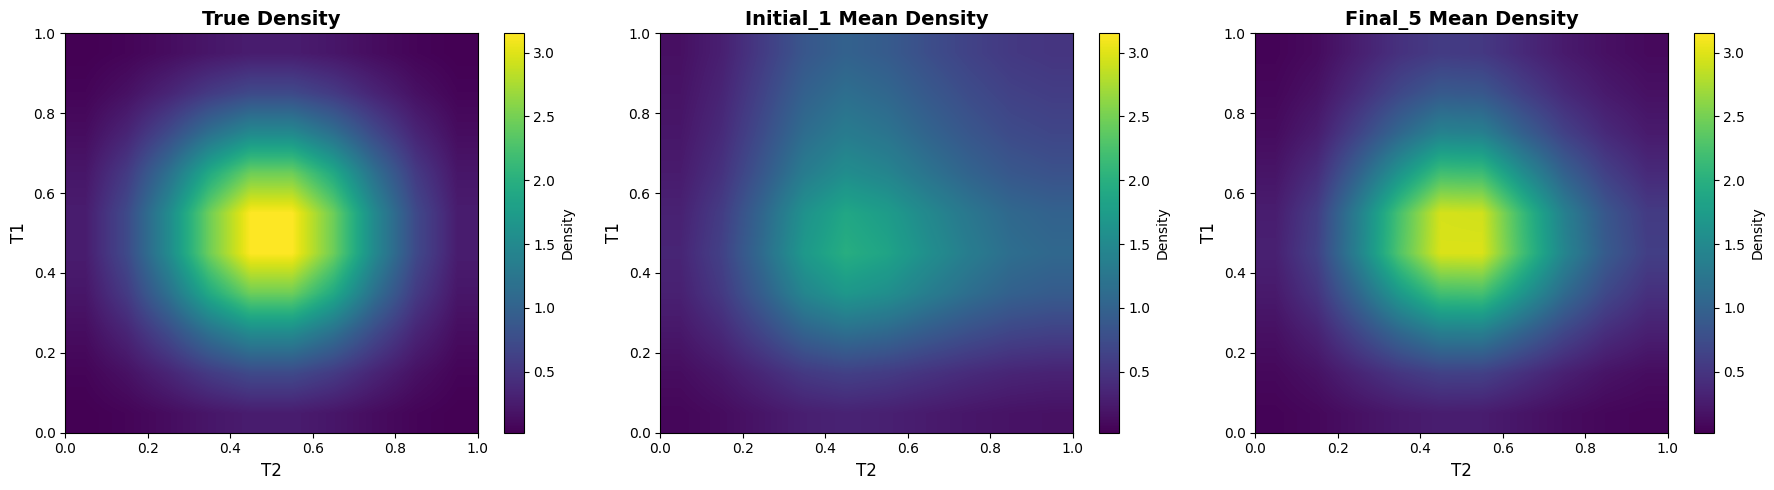

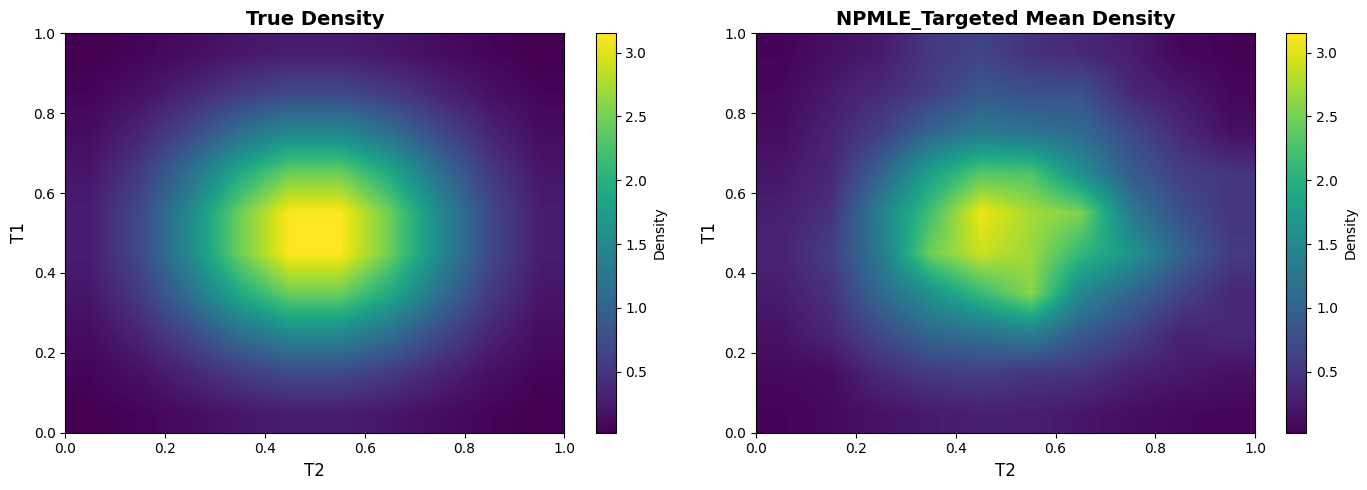

Global bias range: [-1.4007, 1.4007]


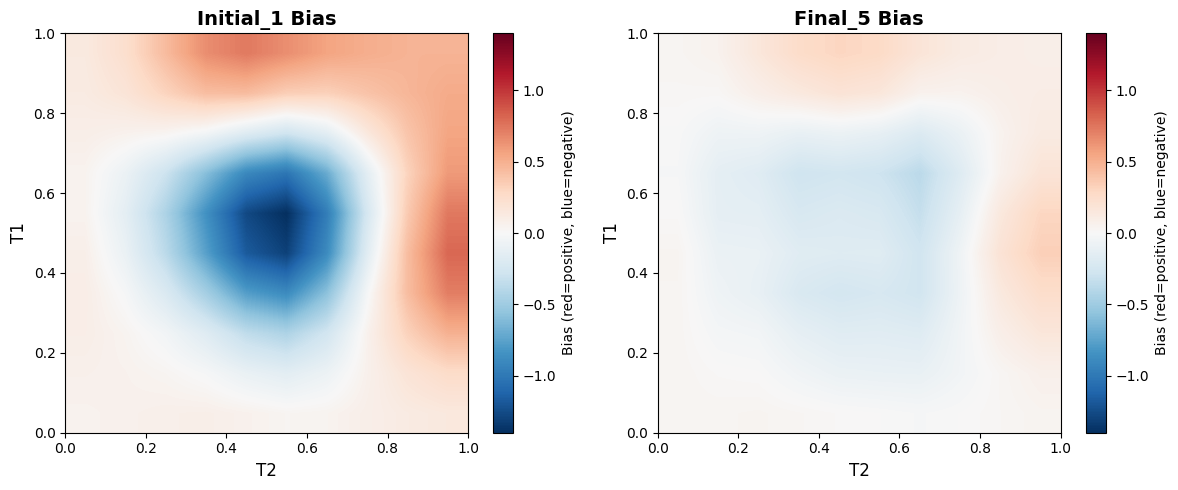

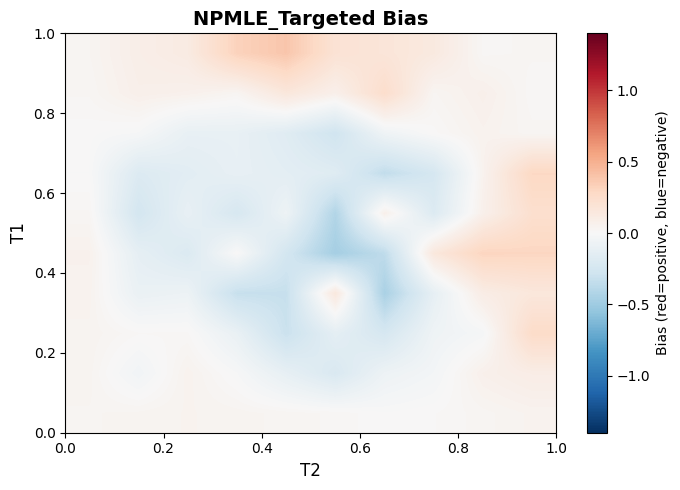

In [9]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

methods = ['Initial_1', 'Final_5', 'NPMLE_Targeted']

# First, determine the global min/max for consistent color scale across all plots
pivot_true = df_summary.pivot(index='T1', columns='T2', values='true_density')
all_values = [pivot_true.values]

for col in methods:
    pivot_mean = df_summary.pivot(index='T1', columns='T2', values=f'{col}_mean')
    all_values.append(pivot_mean.values)

# Get global min/max for color scale
vmin = min([np.min(v) for v in all_values])
vmax = max([np.max(v) for v in all_values])

print(f"Global density range: [{vmin:.4f}, {vmax:.4f}]")

# ============================================================
# Plot 1: Initial_1 and Final_5 comparison (1x3 grid - same row)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: True density
pivot_true = df_summary.pivot(index='T1', columns='T2', values='true_density')
im0 = axes[0].imshow(pivot_true.values, origin='lower', aspect='auto', 
                      cmap='viridis', vmin=vmin, vmax=vmax, interpolation='bilinear',
                      extent=[pivot_true.columns.min(), pivot_true.columns.max(),
                             pivot_true.index.min(), pivot_true.index.max()])
axes[0].set_title('True Density', fontsize=14, fontweight='bold')
axes[0].set_xlabel('T2', fontsize=12)
axes[0].set_ylabel('T1', fontsize=12)
fig.colorbar(im0, ax=axes[0], label='Density')

# Plot 2: Initial_1
pivot_mean = df_summary.pivot(index='T1', columns='T2', values='Initial_1_mean')
im1 = axes[1].imshow(pivot_mean.values, origin='lower', aspect='auto',
                      cmap='viridis', vmin=vmin, vmax=vmax, interpolation='bilinear',
                      extent=[pivot_mean.columns.min(), pivot_mean.columns.max(),
                             pivot_mean.index.min(), pivot_mean.index.max()])
axes[1].set_title('Initial_1 Mean Density', fontsize=14, fontweight='bold')
axes[1].set_xlabel('T2', fontsize=12)
axes[1].set_ylabel('T1', fontsize=12)
fig.colorbar(im1, ax=axes[1], label='Density')

# Plot 3: Final_5
pivot_mean = df_summary.pivot(index='T1', columns='T2', values='Final_5_mean')
im2 = axes[2].imshow(pivot_mean.values, origin='lower', aspect='auto',
                      cmap='viridis', vmin=vmin, vmax=vmax, interpolation='bilinear',
                      extent=[pivot_mean.columns.min(), pivot_mean.columns.max(),
                             pivot_mean.index.min(), pivot_mean.index.max()])
axes[2].set_title('Final_5 Mean Density', fontsize=14, fontweight='bold')
axes[2].set_xlabel('T2', fontsize=12)
axes[2].set_ylabel('T1', fontsize=12)
fig.colorbar(im2, ax=axes[2], label='Density')

plt.tight_layout()
plt.show()

# ============================================================
# Plot 2: NPMLE_Targeted separate comparison (1x2 grid)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: True density
pivot_true = df_summary.pivot(index='T1', columns='T2', values='true_density')
im0 = axes[0].imshow(pivot_true.values, origin='lower', aspect='auto', 
                      cmap='viridis', vmin=vmin, vmax=vmax, interpolation='bilinear',
                      extent=[pivot_true.columns.min(), pivot_true.columns.max(),
                             pivot_true.index.min(), pivot_true.index.max()])
axes[0].set_title('True Density', fontsize=14, fontweight='bold')
axes[0].set_xlabel('T2', fontsize=12)
axes[0].set_ylabel('T1', fontsize=12)
fig.colorbar(im0, ax=axes[0], label='Density')

# Plot 2: NPMLE_Targeted
pivot_mean = df_summary.pivot(index='T1', columns='T2', values='NPMLE_Targeted_mean')
im1 = axes[1].imshow(pivot_mean.values, origin='lower', aspect='auto',
                      cmap='viridis', vmin=vmin, vmax=vmax, interpolation='bilinear',
                      extent=[pivot_mean.columns.min(), pivot_mean.columns.max(),
                             pivot_mean.index.min(), pivot_mean.index.max()])
axes[1].set_title('NPMLE_Targeted Mean Density', fontsize=14, fontweight='bold')
axes[1].set_xlabel('T2', fontsize=12)
axes[1].set_ylabel('T1', fontsize=12)
fig.colorbar(im1, ax=axes[1], label='Density')

plt.tight_layout()
plt.show()

# ============================================================
# Plot 3: Bias heatmaps with CONSTANT color scale
# ============================================================
# First, find the global min/max bias across all methods for consistent color scale
all_bias_values = []
for col in methods:
    pivot_bias = df_summary.pivot(index='T1', columns='T2', values=f'{col}_bias')
    all_bias_values.append(pivot_bias.values)

# Get the maximum absolute bias across all methods
bias_max = max([max(abs(v.min()), abs(v.max())) for v in all_bias_values])

print(f"Global bias range: [{-bias_max:.4f}, {bias_max:.4f}]")

# Plot Initial_1 and Final_5 bias (1x2 grid)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, col in enumerate(['Initial_1', 'Final_5']):
    pivot_bias = df_summary.pivot(index='T1', columns='T2', values=f'{col}_bias')
    
    im = axes[idx].imshow(pivot_bias.values, origin='lower', aspect='auto',
                          cmap='RdBu_r', vmin=-bias_max, vmax=bias_max, interpolation='bilinear',
                          extent=[pivot_bias.columns.min(), pivot_bias.columns.max(),
                                 pivot_bias.index.min(), pivot_bias.index.max()])
    axes[idx].set_title(f'{col} Bias', fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('T2', fontsize=12)
    axes[idx].set_ylabel('T1', fontsize=12)
    fig.colorbar(im, ax=axes[idx], label='Bias (red=positive, blue=negative)')

plt.tight_layout()
plt.show()

# Plot NPMLE_Targeted bias separately
fig, ax = plt.subplots(1, 1, figsize=(7, 5))

pivot_bias = df_summary.pivot(index='T1', columns='T2', values='NPMLE_Targeted_bias')

im = ax.imshow(pivot_bias.values, origin='lower', aspect='auto',
               cmap='RdBu_r', vmin=-bias_max, vmax=bias_max, interpolation='bilinear',
               extent=[pivot_bias.columns.min(), pivot_bias.columns.max(),
                      pivot_bias.index.min(), pivot_bias.index.max()])
ax.set_title('NPMLE_Targeted Bias', fontsize=14, fontweight='bold')
ax.set_xlabel('T2', fontsize=12)
ax.set_ylabel('T1', fontsize=12)
fig.colorbar(im, ax=ax, label='Bias (red=positive, blue=negative)')

plt.tight_layout()
plt.show()